In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.cm as cm   
import matplotlib.colors as mcolors
from src import import_data as i_d
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

/Users/charles.ozeel/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/charles.ozeel/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
/Users/charles.ozeel/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
i_d.charger_donnees_depuis_bureau()

Dossier trouvé : /Users/charles.ozeel/Desktop/donnees_formule_un
Fichiers CSV trouvés : [PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/circuits.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/status.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/lap_times.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/sprint_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/drivers.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/races.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructors.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/qualifying.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/driver_standings.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees_formule_un/constructor_results.csv'), PosixPath('/Users/charles.ozeel/Desktop/donnees

In [3]:
def horaire_moyen_run_f1(races: pd.DataFrame):
    
    loca = pd.read_csv("f1_grands_prix_locations.csv").copy(deep=True)
    
    races = races.copy(deep=True)
    
    races.replace("\\N", np.nan, inplace=True)
    
    date = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
    
    for _ in date:
        races[_] = pd.to_datetime(races[_])
        
    time = ["time","fp1_time", "fp2_time", "fp3_time", "quali_time", "sprint_time"]
    def time_to_decimal(time_str):
        if pd.isna(time_str):
            return np.nan
        h, m, s = map(int, time_str.split(':'))
        return h + m / 60 + s / 3600
    for _ in time:
        races[_]=races[_].apply(time_to_decimal)
    
    loca.rename(columns = {"Grand Prix": "name"}, inplace = True)
    races = pd.merge(races, loca,how = 'left')
    Long = races.Longitude.unique()
    
    avg = []
    for l in Long:
        a = races[races["Longitude"] == l]
        avg_time_A = [a[_].mean() for _ in time]
        avg.append(avg_time_A)
    for j in range(len(avg[0])):
        data = [avg[i][j] for i in range(len(avg))]
        norm = mcolors.Normalize(vmin=min(data), vmax=max(data))  # Normalisation des valeurs
        cmap = plt.cm.plasma
        shapefile_path = "naturalearth_lowres"
        gdf = gpd.read_file(shapefile_path)
        fig, ax = plt.subplots(figsize=(10, 8))
        gdf.plot(ax=ax)
        scatter = ax.scatter(
            races['Longitude'].unique(),
            races['Latitude'].unique(),
            c=data,
            cmap=cmap,  
            s=50,        
            marker='o',  
            edgecolor='k'  
        )
        fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                     ax=ax,
                     orientation='horizontal',
                     label='Moyenne des temps')
        fig.suptitle(f"Horaire moyen de début de {time[j]}")
        plt.show()

In [4]:
def min_max_pit_stop_drivers(nom_pilote: str, pit_stops: pd.DataFrame, drivers : pd.DataFrame, param: {"min", "max"}):
    pit_stops = pit_stops.copy(deep = True)
    pit_stops["duration"] = pit_stops["milliseconds"]*(10**(-3))
    pit_stop_min = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "min"}).reset_index()
    pit_stop_max = pit_stops.groupby(["raceId","driverId"]).agg({"duration": "max"}).reset_index()
    a = pd.merge(drivers, pit_stop_min, on="driverId", how="left")
    a.rename(columns={"duration": "min_pit_stop"}, inplace=True)
    a = pd.merge(a, pit_stop_max, on=["driverId", "raceId"], how="left")
    a.rename(columns={"duration": "max_pit_stop"}, inplace=True)
    a["min_pit_stop"] = a["min_pit_stop"].astype(float)
    a["max_pit_stop"] = a["max_pit_stop"].astype(float)
    a = a[ ~a["min_pit_stop"].isna()]
    a = a[ ~a["max_pit_stop"].isna()]
    drivers_mean_min_pit_stop = a.groupby("driverRef").agg({"min_pit_stop": "mean"}).reset_index()
    drivers_mean_max_pit_stop = a.groupby("driverRef").agg({"max_pit_stop": "mean"}).reset_index()
    if param == 'min':
        return drivers_mean_min_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote]
    else:
        return drivers_mean_max_pit_stop[drivers_mean_max_pit_stop["driverRef"] == nom_pilote] 
    

In [5]:
def generer_table_fichier(nom_fichier_recherche):
    import os
    dossier = os.path.join(os.path.expanduser("~"), "Desktop", "donnees_formule_un")
    if not os.path.isdir(dossier):
        raise ValueError("Le fichier 'donnees_formule_un' est introuvable sur votre bureau.")
        print("Le dossier n'existe pas :", dossier)
        return
    for nom_fichier in os.listdir(dossier):
        chemin_fichier = os.path.join(dossier, nom_fichier)
        if os.path.isfile(chemin_fichier):
            nom_sans_ext = os.path.splitext(nom_fichier)[0]
            if nom_sans_ext == nom_fichier_recherche:
                with open(chemin_fichier, 'r', encoding='utf-8') as f:
                    for ligne in f:
                        yield ligne.strip()

In [6]:
def nbr_victoire_joueurs():
    count = 0
    joueurs_points = dict()
    begin = 0
    end = 0
    for ligne in generer_table_fichier("driver_standings"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 2:
                        begin = i
                    if count_coma == 3:
                        end = i
                        break
            keys = ligne[begin+1 :end]
            victory = ligne[-1]
            if keys in joueurs_points:
                joueurs_points[keys] = joueurs_points[keys] + int(victory)
            else:
                joueurs_points[keys] = int(victory)
        count += 1
    return joueurs_points

In [7]:
i = 0
for ligne in generer_table_fichier("driver_standings"):
    if i < 3:
        print(ligne)
        i+=1
    else:
        break
    

driverStandingsId,raceId,driverId,points,position,positionText,wins
1,18,1,10,1,"1",1
2,18,2,8,2,"2",0


In [8]:
def nbr_points_joueurs():
    count = 0
    joueurs_points = dict()
    begin_name = 0
    end_name = 0
    begin_points = 0
    end_points = 0
    for ligne in generer_table_fichier("driver_standings"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 2:
                        begin_name = i
                    if count_coma == 3:
                        end_name = i
                        begin_points = i
                    if count_coma == 4:
                        end_points = i
                        break
            keys = ligne[begin_name+1 :end_name]
            points = ligne[begin_points+1 :end_points]
            if keys in joueurs_points:
                joueurs_points[keys] = joueurs_points[keys] + float(points)
            else:
                joueurs_points[keys] = float(points)
        count += 1
    return joueurs_points

In [9]:
def nom_joueurs():
    count = 0
    joueurs_nom = dict()
    begin = 0
    end = 0
    for ligne in generer_table_fichier("drivers"):
        if count != 0:
            count_coma = 0
            for i in range(len(ligne)):
                if ligne[i] ==",":
                    count_coma +=1
                    if count_coma == 1:
                        begin = i
                    if count_coma == 2:
                        end = i
                        break
            keys = ligne[:begin]
            name = ligne[begin+2 :end-1]
            joueurs_nom[keys] = name
        count += 1
    return joueurs_nom 

In [10]:
def nbr_victoire_ttal_pilote():
    score = nbr_victoire_joueurs()
    pilotes = nom_joueurs()
    return {pilotes[key]: score[key] for key in score if key in pilotes}

In [11]:
def nbr_points_ttal_pilote():
    score = nbr_points_joueurs()
    pilotes = nom_joueurs()
    return {pilotes[key]: score[key] for key in score if key in pilotes}


In [12]:
def classement_absolu_pilote(pilote: str) -> int:
    drivers = nom_joueurs()
    if pilote not in drivers.values():
        raise ValueError(f"{pilote} n'est pas un pilote référencé")
    score1 = nbr_victoire_ttal_pilote()
    score2 = nbr_points_ttal_pilote()
    res = score1[pilote]
    classement = sorted(score1.items(), key = lambda x: x[1], reverse = True)
    resultat = {}
    for i in range(len(classement)):
        resultat[classement[i][0]] = i+1 
    if res != 0:
        print(f"Le pilote '{pilote}' est arrivé premier "
              f"avec {res} victoires de course "
              "tout au long de sa carrière."
              f"Il aura marqué au total {score2[pilote]}")
    else:
        print(f"Le pilote {pilote} n'a pas de classement "
              "car il n'a aucune victoire de course sur "
              "toute sa carrière."
              f" Il aura marqué au total {score2[pilote]} points.")

    return res

In [13]:
def ttal_vict_pts_pilote(pilote: str)-> list:
    victory = nbr_victoire_ttal_pilote()
    points = nbr_points_ttal_pilote()
    if pilote not in victory.keys():
        raise ValueError(f"{pilote} n'est pas un pilote référencé")
    table = {key : [victory[key],points[key]] for key in victory }
    return table[pilote]

In [14]:
victory = nbr_victoire_ttal_pilote()
points = nbr_points_ttal_pilote()
table = {key : [victory[key],points[key]] for key in victory }

In [15]:
victory_ = [table[key][0] for key in table]
points_ = [table[key][1] for key in table]

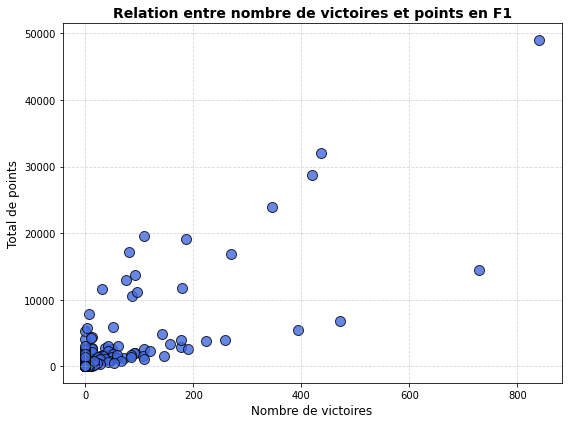

In [16]:
plt.figure(figsize=(8, 6))  # Taille de la figure

plt.scatter(victory_, points_, color='royalblue', edgecolors='k', s=100, alpha=0.8)
plt.title('Relation entre nombre de victoires et points en F1', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de victoires', fontsize=12)
plt.ylabel('Total de points', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Coefficient (slope) : 43.30
Ordonnée à l'origine (intercept) : 122.52
Score R² du modèle : 0.6561


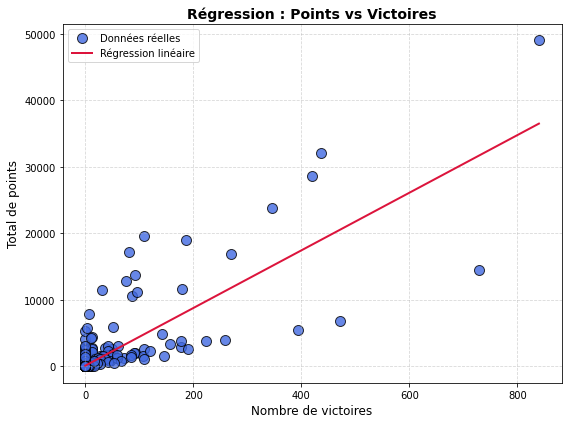

In [17]:
X = np.array(victory_).reshape(-1, 1)
y = np.array(points_)
model = LinearRegression()
model.fit(X, y)
score = model.score(X, y)
print(f"Coefficient (slope) : {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine (intercept) : {model.intercept_:.2f}")
print(f"Score R² du modèle : {score:.4f}")
x_range = np.linspace(min(victory_), max(victory_), 100).reshape(-1, 1)
y_pred = model.predict(x_range)
plt.figure(figsize=(8, 6))
plt.scatter(victory_, points_, color='royalblue', edgecolors='k', s=100, alpha=0.8, label='Données réelles')
plt.plot(x_range, y_pred, color='crimson', linewidth=2, label='Régression linéaire')
plt.title('Régression : Points vs Victoires', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de victoires', fontsize=12)
plt.ylabel('Total de points', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


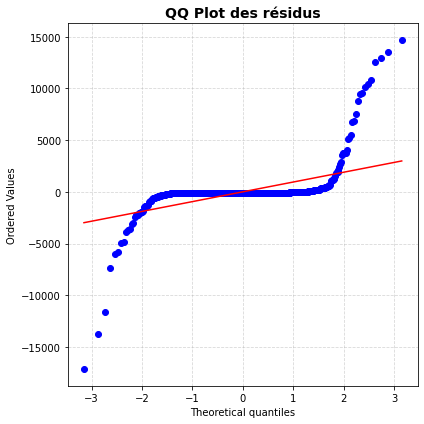

In [18]:
y_pred = model.predict(X)
residuals = y - y_pred
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot des résidus", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

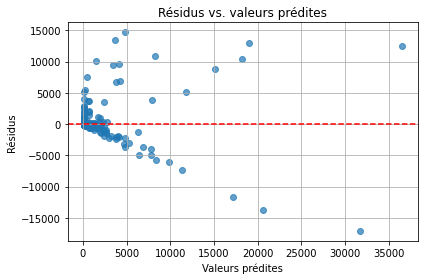

In [19]:
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs. valeurs prédites")
plt.grid(True)
plt.tight_layout()
plt.show()

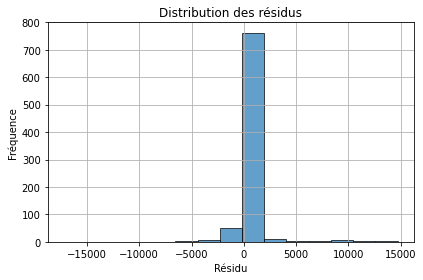

In [20]:
plt.hist(residuals, bins=15, edgecolor='black', alpha=0.7)
plt.title("Distribution des résidus")
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()